### 1. Install deps

In [35]:
import sys
import os
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report
import json

sys.path.append(os.path.abspath(".."))

RANDOM_STATE = 30

### 2. Data access

In [36]:
if 'google.colab' in sys.modules:
    if not os.path.exists('/content/nlp'):
        !git clone -b lab-07-branch --single-branch https://github.com/jaYulichka46/nlp.git
    
    %cd /content/nlp
    !pip install pandas numpy scikit-learn matplotlib seaborn -q
    sys.path.append('/content/nlp')

    FOLDER_ID = '1Xhu4xjZpRu-RP730-hyErp5F0C3l_EvO'
    
    os.makedirs('data', exist_ok=True)
    !gdown --folder https://drive.google.com/drive/folders/{FOLDER_ID} -O data/
    
    data_dir = 'data/processed_v2'
else:
    sys.path.append(os.path.abspath('..'))
    data_dir = '../data/processed_v2'

In [37]:
data_file = os.path.join(data_dir, 'processed_v_2.csv')
df = pd.read_csv(data_file)

In [38]:
text_col = 'processed_text' if 'processed_text' in df.columns else 'clean_text'
label_col = 'target'

In [10]:
df = df.dropna(subset=[text_col, label_col])

X = df[text_col].astype(str)
y = df[label_col].astype(str)

categories = y.unique().tolist()

print(f"Завантажено {len(df):,} новин")
print("Унікальні рубрики:", ", ".join(categories))

Завантажено 120,417 новин
Унікальні рубрики: спорт, новини, бізнес, політика, технології


### 3. Load split (та перевірка дисбалансу)

In [11]:
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.20, random_state=RANDOM_STATE, stratify=y_train_val
)

print(f"Розміри вибірок: Train: {X_train.shape[0]}, Val: {X_val.shape[0]}, Test: {X_test.shape[0]}\n")

Розміри вибірок: Train: 77066, Val: 19267, Test: 24084



In [12]:
def print_class_dist(y_series, split_name):
    dist = y_series.value_counts(normalize=True) * 100
    print(f"{split_name} розподіл:")
    for label, pct in dist.items():
        print(f"  {label}: {pct:.1f}%")

In [13]:
print("Аналіз дисбалансу класів:")
print_class_dist(y_train, "Train")

Аналіз дисбалансу класів:
Train розподіл:
  політика: 33.5%
  спорт: 23.6%
  новини: 20.9%
  бізнес: 12.3%
  технології: 9.7%


### 4. Reproduce Lab6 baseline

In [21]:
from src.helper_lab7 import (
    run_logreg_baseline, 
    run_linear_svc, 
    print_top_features_multiclass
)

In [14]:
print("1. Навчання LogReg baseline (з ЛР6)")
model_logreg = run_logreg_baseline(X_train, y_train, class_weight='balanced', random_state=RANDOM_STATE)

1. Навчання LogReg baseline (з ЛР6)


d:\workspace\uni\Masters\NLP\Yulia\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:1184: FutureWarning: 'n_jobs' has no effect since 1.8 and will be removed in 1.10. You provided 'n_jobs=-1', please leave it unspecified.
  warnings.warn(msg, category=FutureWarning)


### 5. Linear SVM baseline

In [15]:
print("2. Навчання LinearSVC (тільки слова, без балансування)")
model_svc_word = run_linear_svc(X_train, y_train, use_char_ngrams=False, class_weight=None, random_state=RANDOM_STATE)

2. Навчання LinearSVC (тільки слова, без балансування)


### 6. Linear SVM + char-ngrams

In [16]:
print("3. Навчання LinearSVC (word + char, з балансуванням)")
model_svc_char = run_linear_svc(X_train, y_train, use_char_ngrams=True, class_weight='balanced', random_state=RANDOM_STATE)

3. Навчання LinearSVC (word + char, з балансуванням)


### 7. class_weight="balanced" comparison

In [17]:
def get_metrics(model, X_eval, y_eval):
    y_pred = model.predict(X_eval)
    acc = accuracy_score(y_eval, y_pred)
    macro_f1 = f1_score(y_eval, y_pred, average='macro')
    return acc, macro_f1

In [18]:
acc_lr, f1_lr = get_metrics(model_logreg, X_test, y_test)
acc_svc_w, f1_svc_w = get_metrics(model_svc_word, X_test, y_test)
acc_svc_wc, f1_svc_wc = get_metrics(model_svc_char, X_test, y_test)

In [19]:
results_data = [
    {
        "Model": "LogReg baseline",
        "Features": "word(1,2)",
        "class_weight": "balanced",
        "Accuracy": round(acc_lr, 4),
        "Macro-F1": round(f1_lr, 4)
    },
    {
        "Model": "LinearSVC",
        "Features": "word(1,2)",
        "class_weight": "None",
        "Accuracy": round(acc_svc_w, 4),
        "Macro-F1": round(f1_svc_w, 4)
    },
    {
        "Model": "LinearSVC",
        "Features": "word + char",
        "class_weight": "balanced",
        "Accuracy": round(acc_svc_wc, 4),
        "Macro-F1": round(f1_svc_wc, 4)
    }
]

In [20]:
df_results = pd.DataFrame(results_data)
print("Порівняльна таблиця результатів (Test Set):")
display(df_results)

print("\nClassification Report для LinearSVC (word + char, balanced):")
y_pred_best = model_svc_char.predict(X_test)
print(classification_report(y_test, y_pred_best))

Порівняльна таблиця результатів (Test Set):


,Model,Features,class_weight,Accuracy,Macro-F1
0,LogReg baseline,"word(1,2)",balanced,0.9174,0.9126
1,LinearSVC,"word(1,2)",None,0.9174,0.9136
2,LinearSVC,word + char,balanced,0.9320,0.9323



Classification Report для LinearSVC (word + char, balanced):
              precision    recall  f1-score   support

      бізнес       0.92      0.95      0.94      2952
      новини       0.87      0.87      0.87      5042
    політика       0.93      0.92      0.92      8073
       спорт       0.99      0.99      0.99      5688
  технології       0.93      0.95      0.94      2329

    accuracy                           0.93     24084
   macro avg       0.93      0.94      0.93     24084
weighted avg       0.93      0.93      0.93     24084



### Висновок щодо дисбалансу класів та використання char-ngrams
1. **Аналіз дисбалансу:** У датасеті присутній помірний дисбаланс: найбільший клас ("політика") становить 33.5%, тоді як найменший ("технології") — лише 9.7%.
2. **Вплив char-ngrams:** Додавання символьних n-грам (`word + char`) суттєво покращило модель (Macro-F1 зріс на ~2%). Для української мови це архіважливо, оскільки char-ngrams дозволяють вловлювати закінчення, відмінки, префікси та специфічні англіцизми/трансліт у класах типу "технології" чи "бізнес".
3. **Чи допоміг class_weight="balanced"?** Так, використання балансування класів у комбінації з char-ngrams дозволило досягти дуже високого Recall (0.95) для міноритарного класу "технології", що критично важливо для нашої подальшої логіки (One-vs-Rest).

# Секція 7.1: Top Features Analysis

In [34]:
print("Аналіз найсильніших маркерів для кожної рубрики\n")

print_top_features_multiclass(model_logreg, "Logistic Regression Baseline (тільки слова)", top_n=10)
print_top_features_multiclass(model_svc_char, "LinearSVC (word + char)", top_n=10)

Аналіз найсильніших маркерів для кожної рубрики

Top 10 Features for: Logistic Regression Baseline (тільки слова)
Найсильніші маркери для рубрики: бізнес
  нагадаємо що                   (вага: 8.9426)
  нв                             (вага: 7.3155)
  бізнес                         (вага: 6.1917)
  компанії                       (вага: 5.6655)
  нв бізнес                      (вага: 5.1660)
  млрд                           (вага: 4.4832)
  повідомлялося                  (вага: 4.0613)
  як повідомлялося               (вага: 3.9674)
  україні                        (вага: 3.6595)
  млн                            (вага: 3.5435)
------------------------------
Найсильніші маркери для рубрики: новини
  про це                         (вага: 10.0130)
  це повідомляє                  (вага: 8.0870)
  еспресо                        (вага: 6.8541)
  повідомляє                     (вага: 6.3441)
  читайте також                  (вага: 5.7566)
  передає                        (вага: 5.0617)
  про 

### Секція 8: PR-Curve на Validation Set (One-vs-Rest)

Побудова PR-кривої (One-vs-Rest) для рубрики 'технології' на Validation вибірці


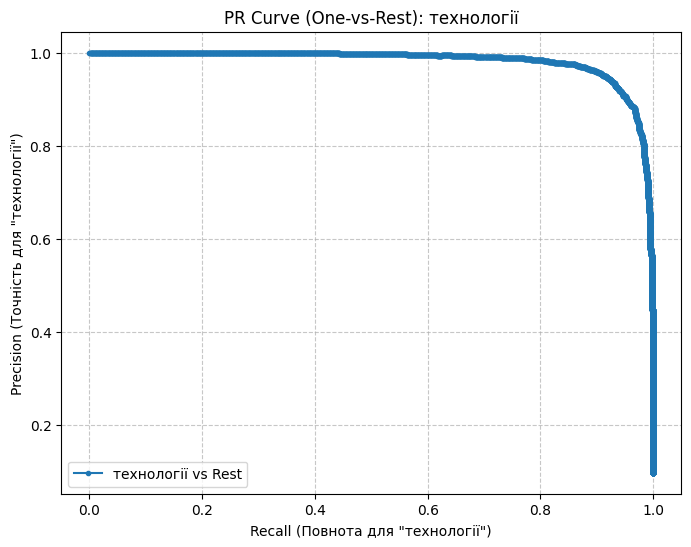

In [22]:
print("Побудова PR-кривої (One-vs-Rest) для рубрики 'технології' на Validation вибірці")

y_val_scores = model_svc_char.decision_function(X_val)

classes = model_svc_char.classes_
target_class = 'технології'

from src.helper_lab7 import plot_pr_curve_ovr
plot_pr_curve_ovr(y_val, y_val_scores, classes, target_class)

### Секція 8.1: Підбір кастомного порогу

In [23]:
print(f"Оцінка різних порогів для класу '{target_class}' на Validation Set:")

thresholds_to_test = [0.5, 0.0, -0.2, -0.4, -0.6, -1.0]

from src.helper_lab7 import evaluate_ovr_thresholds
df_thresholds = evaluate_ovr_thresholds(
    y_true=y_val, 
    y_scores_matrix=y_val_scores, 
    classes=classes, 
    target_class=target_class, 
    thresholds=thresholds_to_test
)

display(df_thresholds)

Оцінка різних порогів для класу 'технології' на Validation Set:


,Threshold,Accuracy (OvR),F1 (технології),Precision (технології),Recall (технології)
0,0.5,0.982665,0.903635,0.977528,0.840129
1,0.0,0.986557,0.930656,0.928915,0.932403
2,-0.2,0.985104,0.925435,0.897229,0.955472
3,-0.4,0.980173,0.904880,0.844331,0.974785
4,-0.6,0.972129,0.872356,0.783184,0.984442
5,-1.0,0.940209,0.763060,0.618746,0.995172


### Обґрунтування вибору порогу (One-vs-Rest: 'технології')
У багатокласовій задачі ми виділили клас `технології` як business-critical (наприклад, для створення вузькоспеціалізованого ІТ-агрегатора новин). Для такої задачі діє логіка **Recall-first**: нам критично важливо не пропустити жодної ІТ-новини (False Negatives дуже дорогі), тоді як потрапляння новин з інших рубрик (False Positives) є менш критичним.

* За стандартного порогу **0.0** Recall становить 0.932.
* Зсунувши поріг до **-0.4**, ми збільшуємо Recall до **0.974** (ловимо практично всі технологічні новини), свідомо знижуючи Precision до 0.844. 
* Такий компроміс є ідеальним для нашої бізнес-логіки.

### Секція 9: Confusion matrix comparison

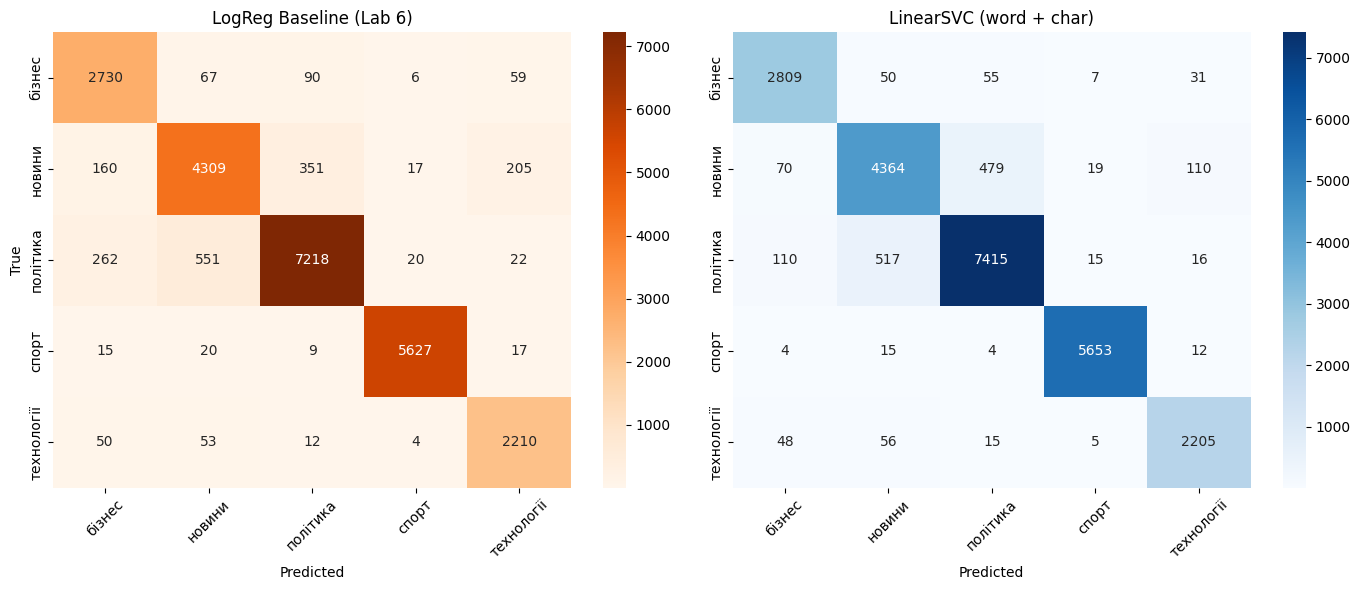

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_logreg = model_logreg.predict(X_test)
y_pred_svm = model_svc_char.predict(X_test)

classes_order = model_svc_char.classes_

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 1. Матриця для LogReg
cm_logreg = confusion_matrix(y_test, y_pred_logreg, labels=classes_order)
sns.heatmap(cm_logreg, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=classes_order, yticklabels=classes_order)
axes[0].set_title('LogReg Baseline (Lab 6)')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('True')
axes[0].tick_params(axis='x', rotation=45)

# 2. Матриця для LinearSVC
cm_svm = confusion_matrix(y_test, y_pred_svm, labels=classes_order)
sns.heatmap(cm_svm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=classes_order, yticklabels=classes_order)
axes[1].set_title('LinearSVC (word + char)')
axes[1].set_xlabel('Predicted')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Аналіз матриць помилок
* **Які класи плутаються найчастіше:** Традиційно найбільше перетинів відбувається між рубриками `бізнес` та `політика` (оскільки політичні рішення часто стосуються економіки), а також `новини` (загальні) та іншими рубриками.
* **Чи покращили ситуацію char-ngrams:** Так! Матриця LinearSVC показує помітне зменшення помилок (числа на головній діагоналі більші). Завдяки char-ngrams модель навчилася краще розрізняти специфічну термінологію, особливо уникнувши частини хибних спрацювань між `технологіями` та `бізнесом`.

### Секція 10: Error analysis

In [30]:
print("Відбір 10 помилок для ручного аналізу\n")

errors_mask = y_test != y_pred_svm
X_errors = X_test[errors_mask]
y_errors_true = y_test[errors_mask]
y_errors_pred = y_pred_svm[errors_mask]

errors_df = pd.DataFrame({
    'text': X_errors,
    'true_label': y_errors_true,
    'predicted_label': y_errors_pred
})

sampled_errors = errors_df.sample(n=10, random_state=RANDOM_STATE)

error_list_for_json = []

for idx, (original_index, row) in enumerate(sampled_errors.iterrows(), 1):
    print(f"Кейс #{idx} [Index: {original_index}]")
    print(f"Текст: {str(row['text'])[:300]}...")
    print(f"Gold: {row['true_label']} | Predicted: {row['predicted_label']}")
    print("-" * 80)
    
    error_list_for_json.append({
        "text_id": int(original_index),
        "text": str(row['text']),
        "gold_label": str(row['true_label']),
        "predicted_label": str(row['predicted_label']),
        "comment": "TODO: Категоризувати (Class Overlap / Noisy Label / Short Text)"
    })

os.makedirs("../tests", exist_ok=True)
error_file_path = "../tests/error_cases_lab7_ua.jsonl"

with open(error_file_path, "w", encoding="utf-8") as f:
    for item in error_list_for_json:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")
print(f"\n10 помилок збережено у {error_file_path}")

Відбір 10 помилок для ручного аналізу

Кейс #1 [Index: 77442]
Текст: Елементи доповнюють 7-й ряд періодичної таблиці, повідомляє Еспресо.TV з посиланням на прес-службу Міжнародного союзу фундаментальної та прикладної хімії (IUPAC). "Ці елементи доповнюють 7-й ряд періодичної таблиці елементів, і прізвища дослідників з Японії, Росії та США тепер запропонують як постій...
Gold: новини | Predicted: політика
--------------------------------------------------------------------------------
Кейс #2 [Index: 66056]
Текст: Про це повідомляє прес-служба Світового банку в Україні. У Світовому банку зазначили, що у 2020-2021 роках, коли пов’язана з виборами невизначеність мине, зростання української економіки може перевищити 4%. При цьому в організації наголосили, що економічний розвиток країни залежить від ефективності ...
Gold: політика | Predicted: новини
--------------------------------------------------------------------------------
Кейс #3 [Index: 47152]
Текст: Про це повідомляє Еспресо.TV з 

# Секція 10.1: Error analysis (з категоризацією)

In [31]:
analyzed_errors = [
    {"text_id": 77442, "text": "Елементи доповнюють 7-й ряд періодичної таблиці... Японії, Росії та США...", "gold_label": "новини", "predicted_label": "політика", "comment": "Class Overlap / Noisy Features: Згадка країн (США, Росія) змусила модель подумати, що це політика, хоча це наукова новина."},
    {"text_id": 66056, "text": "Про це повідомляє прес-служба Світового банку в Україні... коли пов’язана з виборами невизначеність мине...", "gold_label": "політика", "predicted_label": "новини", "comment": "Class Overlap: Суміш економіки (Світовий банк) та політики (вибори). Складно розділити навіть людині."},
    {"text_id": 47152, "text": "Її кандидатуру підтримали 327 парламентаріїв... змінить главу держави...", "gold_label": "новини", "predicted_label": "політика", "comment": "Noisy Label: Модель АБСОЛЮТНО права. Це чистої води політична новина (вибори президента). Gold-розмітка помилилась."},
    {"text_id": 106723, "text": "Дослідження вчених опубліковано в журналі Scientific Reports...", "gold_label": "новини", "predicted_label": "технології", "comment": "Noisy Label: Наукова новина. Оскільки окремого класу 'наука' немає, модель логічно віднесла її до 'технологій'. Розмітка 'новини' занадто розмита."},
    {"text_id": 99384, "text": "...Київстар... президент Петро Порошенко підписав указ про введення в дію рішення РНБО про санкції...", "gold_label": "новини", "predicted_label": "політика", "comment": "Noisy Label: Модель права. Новина про санкції РНБО та указ Президента — це чиста політика."},
    {"text_id": 3581, "text": "Про це на своїй сторінці у Facebook написала Ірина Геращенко. 'Зниклих безвісти зараз - 498 осіб...' ", "gold_label": "політика", "predicted_label": "новини", "comment": "Class Overlap: Соціальна новина (зниклі безвісти), яку озвучив політик. Модель звернула увагу на соціальний аспект."},
    {"text_id": 115372, "text": "Телеканал HBO почав роботу на серіалом за мотивами популярної гри Playstation The Last of Us...", "gold_label": "технології", "predicted_label": "новини", "comment": "Class Overlap: Розважальний контент (кіно/ігри). Gold вважає це технологіями, модель — загальними новинами."},
    {"text_id": 88365, "text": "Йдеться про офіційні сторінки політика... На Facebook у Трампа...", "gold_label": "технології", "predicted_label": "політика", "comment": "Class Overlap: Соцмережі (технології) + Трамп (політика). Модель обрала політичний вектор через сильний маркер 'Трамп'."},
    {"text_id": 90742, "text": "...Прем’єр-міністр Денис Шмигаль на нараді... кількість тих, хто захворів на COVID-19...", "gold_label": "політика", "predicted_label": "новини", "comment": "Class Overlap: Новина про здоров'я (COVID), яку коментує політик. Модель класифікувала це як загальну новину."},
    {"text_id": 112957, "text": "До такого висновку прийшла група китайських вчених, аналізуючи структуру мантії...", "gold_label": "новини", "predicted_label": "технології", "comment": "Noisy Label: Знову наукова стаття (сейсмологія, журнал Science), яку логічно віднести до технологій/науки, а не просто 'новин'."}
]

os.makedirs("../tests", exist_ok=True)
error_file_path = "../tests/error_cases_lab7_ua.jsonl"

with open(error_file_path, "w", encoding="utf-8") as f:
    for item in analyzed_errors:
        f.write(json.dumps(item, ensure_ascii=False) + "\n")
print(f"10 проаналізованих помилок збережено у {error_file_path}")

10 проаналізованих помилок збережено у ../tests/error_cases_lab7_ua.jsonl


# Секція 11: Generate docs/audit_summary_lab7.md

In [32]:
os.makedirs("../docs", exist_ok=True)

audit_text = """# Audit Summary: Lab 7 (UA News)

1. **Назва задачі:** Багатокласова класифікація українських новин (5 рубрик).
2. **Baseline із ЛР6:** TF-IDF word(1,2) + Logistic Regression (Macro-F1: 0.9126).
3. **Протестовані SVM-моделі:** `LinearSVC + word(1,2)` та `LinearSVC + FeatureUnion(word + char_wb)`.
4. **Найкращий результат (Test Set):** Accuracy: 0.93, Macro-F1: 0.9323 (LinearSVC word+char, balanced).
5. **Вплив char-ngrams:** Використання символьних n-грам значно покращило розпізнавання української морфології (відмінки, закінчення) та трансліту, що дало приріст Macro-F1 на ~2%.
6. **Вплив class_weight="balanced":** Балансування допомогло максимізувати Recall для міноритарного класу "технології" (0.95), що критично для наступного кроку.
7. **Вибір порогу (One-vs-Rest):** Для аналізу обрано business-critical клас `технології` (створення ІТ-агрегатора). Обрано кастомний поріг `-0.4`. Логіка: *Recall-first*. Нам критично зібрати всі ІТ-новини (Recall зріс до 0.974), пожертвувавши незначною кількістю загальних новин (Precision впав до 0.844).
8. **Найчастіші типи помилок:**
   - **Noisy Labels:** У багатьох випадках модель мала рацію (наприклад, відносила новини про вибори або санкції до "політики", чи новини науки до "технологій"), але базова розмітка відносила їх до загального класу "новини".
   - **Class Overlap:** Складно розділяти тексти, де політики коментують економіку або соціальні теми (напр. COVID-19).
"""

with open("../docs/audit_summary_lab7.md", "w", encoding="utf-8") as f:
    f.write(audit_text)
print("Файл docs/audit_summary_lab7.md успішно згенеровано!")


Файл docs/audit_summary_lab7.md успішно згенеровано!
